# Bitcoin Transaction Graph Neural Network

This notebook is to demonstrate an application of Graph Neural Network in classification of bitcoin transactions. We will utilize self-supervised training to observe if there are any improvements observed in training.
The dataset used in the notebook is the [Elliptic Bitcoin Dataset on Kaggle](https://www.kaggle.com/datasets/ellipticco/elliptic-data-set?select=elliptic_bitcoin_dataset). 


Note: Some of the code written for defining the model and training loops have been uplaoded to my [data science projects Github Repo](https://github.com/alenreuel/data_science_projects/tree/main/bitcoin_GNN). If you are interested in learning more about it then feel free to have a look at it.


All necessary imports are shown in the code block below.

In [1]:
%load_ext autoreload
%autoreload 2

# to filter warning texts
import warnings
warnings.filterwarnings("ignore")

# OS operations
import os
from pathlib import Path
# common datascience libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# deep-learning libraries
import torch
from torch import nn
from torch_geometric.data import Data# library for geometric deep learning
from torch_geometric.loader import NeighborLoader
# from sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# code written by myself
import NN_models
import train_loop

train_loop.device = "cuda"

Using device: cuda


In [2]:
torch.__version__

'2.7.1+cu126'

## Background on Semi-Supervised Learning

Before dwelving into the Dataset and Training process I'll first provide a brief background on Semi-supervised learning.  

*Semi-Supervised Learning* is a method to utilize both labelled and unlabelled data for training models. This technique is used to supplement a supervised learning algorithm by supplementing the model with information from unlabbelled data to improve it's predictions. 

It can be useful technique for cases when labeling a dataset is difficult. For example: It is fairly simple for a human being to label dog/cat images, however, obtaining labels for more specialized applications like genomics requires special expertise. Therefore, a method to automatically label information present within the unlabelled data could be a tool to improve our predictions.

Semi-supervised Learning requires to satisfy some of the follwoing assumptions:

- **Cluster Assumption:** Datapoints present in a cluster at the input space should belong to identical classes.
- **Smoothness Assumption:** If 2 datapoints are close to each other. They should have similar outputs.
- **Low-density Assumption:** A decision boundary should not pass through high density regions.
- **Manifold Assumption:** If a high-dimensional space is transformed to a low dimensional space, then the labels should not change.

For this example, we are going to assume that the above relationships are satisfied.

Overall, there are 2 methods to perform semi-supervised learning:

1) **Transductive Learning**: Methods to use available labels to make predictions about unlabelled examples. An example of this method is Label Propogation, which computes labels of unlabelled datapoints based on proximity to labelled ones.

2) **Inductive Learning**: Directly training a classifier using both a pseudo-labeling step and an unsupervised pre-processing step.

In this notebook I have demonstrated an **Inductive Learning Approach.**



## Dataset

The dataset is a Graph Dataset which has been represented by 3 csv files:

1) 'elliptic_txs_classes.csv': classes of each node (illicit, licit, unlabelled)
2) 'elliptic_txs_edgelist.csv': edges of the graph dataset 
3) 'elliptic_txs_features.csv': node features dataset (features associated with each node)

In [3]:
cur_path = Path().resolve()
dataset_dir = Path().resolve().parent/"datasets/Graph_Datasets/elliptic_bitcoin_dataset/"
csv_f =  os.listdir(dataset_dir)
for i in csv_f:
    if "edgelist" in i:
        edgelist_csv = i
    elif "classes" in i:
        node_class_csv = i
    elif "features" in i:
        node_features_csv = i

### Node Level Data

The number of features at the node level are 166. We can observe that nodes have some labels to them, to be able to use them efficiently with torch_geometric library we shall rename them for "0" to "len(nodes)-1" .

In [4]:
graph_node_f_df = pd.read_csv(dataset_dir/f"{node_features_csv}", header=None, engine="pyarrow")
graph_node_f_df = graph_node_f_df.rename(columns={0:"Node"})
i = 1
for col in graph_node_f_df.columns[1:]:
    graph_node_f_df.rename(columns={col:f"Feature_{col}"})
graph_node_f_df.head(5)

,Node,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [5]:
nodes = {} # map node_ids to integers for using with torch_geometric 
ind = 0
for i in graph_node_f_df["Node"]:
    if i not in nodes.keys():
        nodes[i] = ind
        ind += 1
    else:
        continue
graph_node_f_df["Node"] = graph_node_f_df["Node"].apply(lambda x: nodes[x]) # rename nodes
print(len(nodes))

203769


Most columns appear to be a float64 dtype. From the cell below, it can be observed that columns: Node and 1 are the only columns with dtype int64. While "Node" is an id column, however, "Feature 1" is related to time steps ranging from 1 to 48. We will be treating it as a categorical data type.

In [6]:
graph_node_f_df.dtypes

Node      int64
1         int64
2       float64
3       float64
4       float64
         ...   
162     float64
163     float64
164     float64
165     float64
166     float64
Length: 167, dtype: object

In [7]:
graph_node_f_df.dtypes.drop_duplicates()

Node      int64
2       float64
dtype: object

Based on the values in column 1. We can see that this is most likely a categorical feature and will be one hot-encoded during the training process. 

In [8]:
graph_node_f_df[1].drop_duplicates()

0          1
7880       2
12424      3
19045      4
24738      5
31541      6
35869      7
41917      8
46374      9
51370     10
58097     11
62393     12
64440     13
68968     14
70990     15
74629     16
77604     17
80989     18
82965     19
86471     20
90762     21
94299     22
100193    23
104358    24
108950    25
111264    26
113787    27
114876    28
116529    29
120804    30
123287    31
126103    32
130628    33
133779    34
136265    35
141772    36
148165    37
151471    38
154362    39
157122    40
161603    41
166945    42
174085    43
179148    44
184123    45
189721    46
193240    47
198361    48
201315    49
Name: 1, dtype: int64

### Edge Data

The orgin and terminating nodes for each edge will have to be re-labelled with respect to the node ids in the node level dataset.

In [9]:
graph_edges_df = pd.read_csv(dataset_dir/f"{edgelist_csv}", engine="pyarrow")
graph_edges_df.head(5)

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [10]:
graph_edges_df["txId1"] = graph_edges_df["txId1"].apply(lambda x: nodes[x])
graph_edges_df["txId2"] = graph_edges_df["txId2"].apply(lambda x: nodes[x]) 
graph_edges_df.head(5)

,txId1,txId2
0,0,1
1,2,3
2,4,5
3,6,7
4,8,9


### Node Classes- Outputs

The outputs have been given the labels:
- **-1** for unlabelled.
- **0** for licit transactions.
- **1** for illicit transactions.

In [11]:
graph_node_class = pd.read_csv(dataset_dir/f"{node_class_csv}", engine="pyarrow")
graph_node_class['txId'] = graph_node_class['txId'].apply(lambda x: nodes[x])
graph_node_class['Node'] = graph_node_class['txId']
graph_node_class = graph_node_class.drop(columns=["txId"])
graph_node_class["class"] = graph_node_class["class"].apply(lambda x: -1 if x=="unknown" else int(x)-1)

In [12]:
graph_node_class["class"].value_counts()

class
-1    157205
 1     42019
 0      4545
Name: count, dtype: int64

The overall class distribution shows we have:

- 77.15% Unlabelled examples.
- 2.23% Labelled Illicit Transaction.
- 20.62 Labelled Licit Transaction.

After excluding the unlabelled examples, about 10% are illicit. Implying the given dataset is Imbalanced.

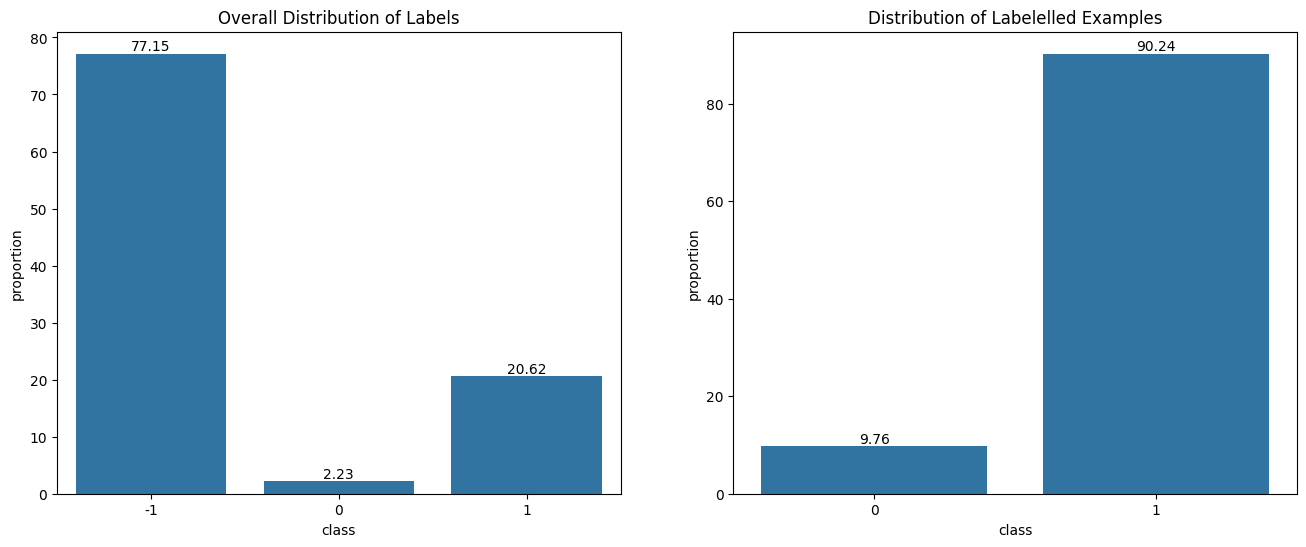

In [13]:
plt.subplots(1,2, figsize=(16,6))
plt.subplot(1,2,1)
plt.title("Overall Distribution of Labels")
ax = sns.barplot(data=round(graph_node_class["class"].value_counts(normalize=True) * 100, 2))
ax.bar_label(ax.containers[0], fontsize=10)
plt.subplot(1,2,2)
plt.title("Distribution of Labelelled Examples")
ax = sns.barplot(data=round(graph_node_class[graph_node_class["class"]!=-1]["class"].value_counts(normalize=True) * 100, 2))
ax.bar_label(ax.containers[0], fontsize=10)
plt.show()

## Deep Learning- Graph NN

### Data Preparation

#### Graph Dataset Peparation

Firstly, the edges and nodes have to be defined. 

All information of the graph will be embedded into a [Data object](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.data.Data.html) from the torch_geometric library. 

In [14]:
# edges represetnation as a tensor
edge_index= torch.from_numpy(graph_edges_df.to_numpy()).type(torch.long)
# convert node names to a long tensor
nodes = torch.from_numpy(graph_node_f_df.to_numpy()[:,0]).type(torch.long)
# convert nodes features to a tensor
node_features = torch.from_numpy(graph_node_f_df.to_numpy()[:,1:]).type(torch.float)
# one hot enocoding for first column
node_feature_cat = node_features[:,0].type(torch.long)
node_feature_cat = nn.functional.one_hot(node_feature_cat).type(torch.float)
# concatenating tensors
node_features = torch.cat((node_feature_cat, node_features[:,1:]), dim=1).type(torch.float)
# grouping into classes

node_classes = torch.from_numpy(graph_node_class.to_numpy()[:,0].reshape(-1)).type(torch.long)
print(node_features, nodes, node_classes)

tensor([[ 0.0000,  1.0000,  0.0000,  ..., -0.0975, -0.1206, -0.1198],
        [ 0.0000,  1.0000,  0.0000,  ..., -0.0975, -0.1206, -0.1198],
        [ 0.0000,  1.0000,  0.0000,  ..., -0.1837, -0.1206, -0.1198],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ..., -0.0975, -0.1206, -0.1198],
        [ 0.0000,  0.0000,  0.0000,  ..., -0.1406,  1.5197,  1.5214],
        [ 0.0000,  0.0000,  0.0000,  ..., -0.1406,  1.5197,  1.5214]]) tensor([     0,      1,      2,  ..., 203766, 203767, 203768]) tensor([-1, -1, -1,  ...,  0, -1, -1])


#### Dataset Segregation

In our current dataset, we have unlabeled examples. However, unlike standard machine learning procedures, unlabeled nodes cannot be omitted from the dataset. There exists edges between labelled and unlabeled nodes which can serve as important information which are important for computations in GNN layers.   

The unlabeled nodes do not provide any information to aid training; We do not consider them during training. The labeled data is further split into training, validation and testing sets which also have relationships between each other. 

In summary, we will undergo the following segregations:

1) Dataset -> Unlabeled/Labeled
2) Dataset -> Training/Validation/Testing Set

These segregations will be done through masking.

In [15]:
graph_data = Data(x=node_features, edge_index=edge_index.t().contiguous(), y=node_classes)
graph_data

Data(x=[203769, 215], edge_index=[2, 234355], y=[203769])

In [16]:
print(f'Number of features: {graph_data.num_features}')
print(f'Number of nodes: {graph_data.num_nodes}')
print(f'Number of edges: {graph_data.num_edges}')
print(f'Average node degree: {graph_data.num_edges / graph_data.num_nodes:.2f}')
print(f'Has isolated nodes: {graph_data.has_isolated_nodes()}')
print(f'Has self-loops: {graph_data.has_self_loops()}')
print(f'Is undirected: {graph_data.is_undirected()}')

Number of features: 215
Number of nodes: 203769
Number of edges: 234355
Average node degree: 1.15
Has isolated nodes: False
Has self-loops: False
Is undirected: False


##### Training, validation and testing set creation 

Before, splitting we need to ensure that we only consider labeled examples. The nodes follow 80/10/10 split and a mask is created that represents each set of examples.   

In [17]:
# consider only labelled examples
nodes_df, class__ = graph_node_class[graph_node_class["class"]!=-1]["Node"], graph_node_class[graph_node_class["class"]!=-1]["class"]
# split dataset
train_nodes, test_nodes, y_train, y_test = train_test_split(nodes_df, class__, test_size=0.2, stratify=class__, random_state=22)
val_nodes, test_nodes, y_val, y_test = train_test_split(test_nodes, y_test, test_size=0.5, stratify=y_test, random_state=22)

# mask creation
base_tensor = torch.zeros(len(nodes))

# train mask select only training nodes based on index
train_mask = base_tensor.clone().detach()
train_nodes_tensor = torch.from_numpy(train_nodes.copy().to_numpy())
train_mask[train_nodes_tensor] = 1
graph_data.train_mask = train_mask.type(torch.long).type(torch.bool)

# val mask select only validation nodes based on index.
val_mask = base_tensor.clone().detach()
val_nodes_tensor = torch.from_numpy(val_nodes.copy().to_numpy())
val_mask[val_nodes_tensor] = 1
graph_data.val_mask = val_mask.type(torch.long).type(torch.bool)

# val mask select only validation nodes based on index
test_mask = base_tensor.clone().detach()
test_nodes_tensor = torch.from_numpy(test_nodes.copy().to_numpy())
test_mask[test_nodes_tensor] = 1
graph_data.test_mask = test_mask.type(torch.long).type(torch.bool)

**Important:** During training, only the training mask will be updated when more examples are generated during the semi-supervised learning procedure. The validation and testing sets will remain the same and will be used to monitor the performance of a graph network and will be used to verify improvements made in the semi-supervised training procedure.

##### Prepare mask for labeled/unlabeled data

The train, test and validation masks can account for labelled and unlabeled examples, I decided to create an additional mask to keep a track of the original set of labeled and unlabeled examples. 

In [18]:
# unlabelled mask
unlabelled_mask = node_classes.clone().detach().apply_(lambda x: 1 if x==-1 else 0)

graph_data.unlabelled_mask = unlabelled_mask.type(torch.long).type(torch.bool)
graph_data.unlabelled_mask

tensor([ True,  True,  True,  ..., False,  True,  True])

#### Data Loader

The data loader chosen for the implementation is the [Neighbor loader](https://pytorch-geometric.readthedocs.io/en/2.5.1/modules/loader.html#torch_geometric.loader.NeighborLoader) which was introduced in the [Inductive Representation Learning on Large Graphs](https://arxiv.org/abs/1706.02216) paper. This method samples only a fixed size set of neighbors at every iteration, This provides an expected run-time of $O(\prod_{i=1}^{n} S_i)$ where $S_i$ is the number of samples drawn at iteration i. This keeps the computational footprint predictable compared to a mini-batching where all the neighbors are considered which results in a time-complexity of $O(|N|)$. The paper reported they received good results with $K=2$ and $S_1 . S_2 <= 500$ on the tasks they utilized for their studies, which motivated my selection of the parameters ``num_neighbors=[20]*2`` in our case.

In [19]:
loader = NeighborLoader(graph_data, num_neighbors=[20]*2, input_nodes=graph_data.train_mask, batch_size=64)

In [20]:
test= next(iter(loader))
test

Data(x=[364, 215], edge_index=[2, 337], y=[364], train_mask=[364], val_mask=[364], test_mask=[364], unlabelled_mask=[364], n_id=[364], e_id=[337], input_id=[64], batch_size=64)

## Model Architecture

### Graph Neural Networks (GNNs)

Graph prediction tasks can be either at the node level, edge level or a graph level. This project, we are focusing on node-level tasks and since, there are relationships between nodes in a graph which make predictions about one node interdependent on other nodes. 

Similar to CNNs, convolution operations are also performed on graphs through a graph convolution function. The objective of a graph convolution is to update the feature embeddings of a node through a message passing phenomenon, which has been described in the image below and can be more formally described by the equation below:

$$h^k_v = \sigma (W_k \sum_{u\epsilon N(v)} \frac{{h^{k-1}_u}}{N(v)} + B_k h^{k-1}_v)$$

where $h^k_v$ is the embedding of node v in layer k, $u$ are the neighbors of $v$, $h^{k-1}_u$ are embeddings of u at layer k-1. $W_k$ and $B_k$ are learnable weights at each layer.

![GNN Forward Propagation](https://i0.wp.com/neptune.ai/wp-content/uploads/2022/10/Many-Layers-1.png?resize=763%2C317&ssl=1 "GNN Forward Propogation")




It was pointed out by the authors of the ["Inductive Representation Learning on Large Graphs"](https://arxiv.org/abs/1706.02216) paper pointed out that the original GCN algorithm in the ["Semi-Supervised Classification with Graph Convolutional Networks"](https://arxiv.org/abs/1609.02907) was meant for semi supervised learning and suitable for inductive setting while suggesting that it does not scale to large graphs. The key idea in their implementation is to maintain the embedding information across multiple layers in the network which is done through

$$h^k_v = \sigma [W_k . AGG(h^{k-1}_u, {u \epsilon N(v)}), B_k h^{k-1}_v]$$

Utilizing the GraphSAGE method helped improve the prediction results in our tasks, implying that the GraphSAGE based layers are able to capture more meaningful relationships amongst illicit transactions.

In [21]:
model = NN_models.GNN_Model(graph_data["x"].shape[1], 1024, 1, 5, 0.1, SAGE=True)
model.type

<bound method Module.type of GNN_Model(
  (layers): ModuleList(
    (0): SAGEConv(215, 1024, aggr=mean)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.1, inplace=False)
    (3): SAGEConv(1024, 1024, aggr=mean)
    (4): ReLU(inplace=True)
    (5): Dropout(p=0.1, inplace=False)
    (6): SAGEConv(1024, 1024, aggr=mean)
    (7): ReLU(inplace=True)
    (8): Dropout(p=0.1, inplace=False)
    (9): SAGEConv(1024, 1024, aggr=mean)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.1, inplace=False)
    (12): SAGEConv(1024, 1, aggr=mean)
  )
)>

# Training



#### Normal Training Loop

In [22]:
t_loop_normal = train_loop.ModelTraining(model, graph_data)
if not os.path.exists(cur_path/"best_ind_model.pth"):
    t_loop_normal.regular_training_loop(cur_path, n_epochs=100)
else:
    t_loop_normal.model.load_state_dict(torch.load(cur_path/"best_ind_model.pth", weights_only=True))

100%|██████████| 99/99 [06:49<00:00,  4.14s/epoch, training_accuracy=100, training_loss=7.91e-11, validation_accuracy=97.9, validation_loss=2.1]  


In [23]:
if not os.path.exists(cur_path/"training_logs_normal.csv"):
    training_logs = t_loop_normal.training_logs
    training_logs_df = pd.DataFrame(training_logs)
    training_logs_df.to_csv("training_logs_normal.csv")
else:
    training_logs_df = pd.read_csv(cur_path/"training_logs_normal.csv").drop(columns=["Unnamed: 0"])
training_logs_df.head(5)

,iter,epoch,training_loss,training_acc,val_loss,val_acc,unlabelled_count
0,0,1,0.243721,0.927198,0.303406,0.933545,tensor(157205)
1,0,2,0.111942,0.963895,0.235314,0.950943,tensor(157205)
2,0,3,0.083619,0.973845,0.343182,0.941596,tensor(157205)
3,0,4,0.068289,0.976965,0.191923,0.957464,tensor(157205)
4,0,5,0.051234,0.982658,0.195929,0.960852,tensor(157205)


#### Semi-Supervised Learning Training Loop

In [24]:
t_loop_self_supervised = train_loop.ModelTraining(model, graph_data)
if not os.path.exists(cur_path/"best_semi_sup_model.pth"):
    t_loop_self_supervised.self_supervised_training_loop(cur_path, n_epochs=10, n_iters=10, threshold=0.75)
else:
    t_loop_self_supervised.model.load_state_dict(torch.load(cur_path/"best_semi_sup_model.pth", weights_only=True))

In [27]:
if not os.path.exists(cur_path/"training_logs_self_supervised.csv"):
    training_logs = t_loop_self_supervised.training_logs
    training_logs_df_ss = pd.DataFrame(training_logs)
    training_logs_df_ss.to_csv("training_logs_self_supervised.csv")
else:
    training_logs_df_ss = pd.read_csv(cur_path/"training_logs_self_supervised.csv").drop(columns=["Unnamed: 0"])
    training_logs_df_ss.head(5)
    training_logs_df_ss = training_logs_df_ss.reset_index()
    training_logs_df_ss["overall_epoch"] = training_logs_df_ss["index"] + 1
    training_logs_df_ss = training_logs_df_ss.drop(columns=["index"])
training_logs_df_ss.head(5)

,iter,epoch,training_loss,training_acc,val_loss,val_acc,unlabelled_count,overall_epoch
0,1,1,0.194420,0.929847,0.226142,0.931713,tensor(157205),1
1,1,2,0.152286,0.964001,0.261516,0.948344,tensor(157205),2
2,1,3,0.083303,0.971241,0.285874,0.942721,tensor(157205),3
3,1,4,0.069585,0.975582,0.267387,0.963627,tensor(157205),4
4,1,5,0.045881,0.983665,0.482487,0.965849,tensor(157205),5


## Results

### Comparison in Training Methods

Before moving on with this section, let us remind ourselves that the dataset is imbalanced. Therefore, it can be assumed that the model will have a tendency to predict a transaction to be licit rather than illicit atleast in the early stages of adding labels. Therefore, the training loss would be expected to improve for our self-supervised case. This can be ascertained by observing the graph below. However, a better indication to observe improvement in our training set would be to observe the training progress in our validation set.

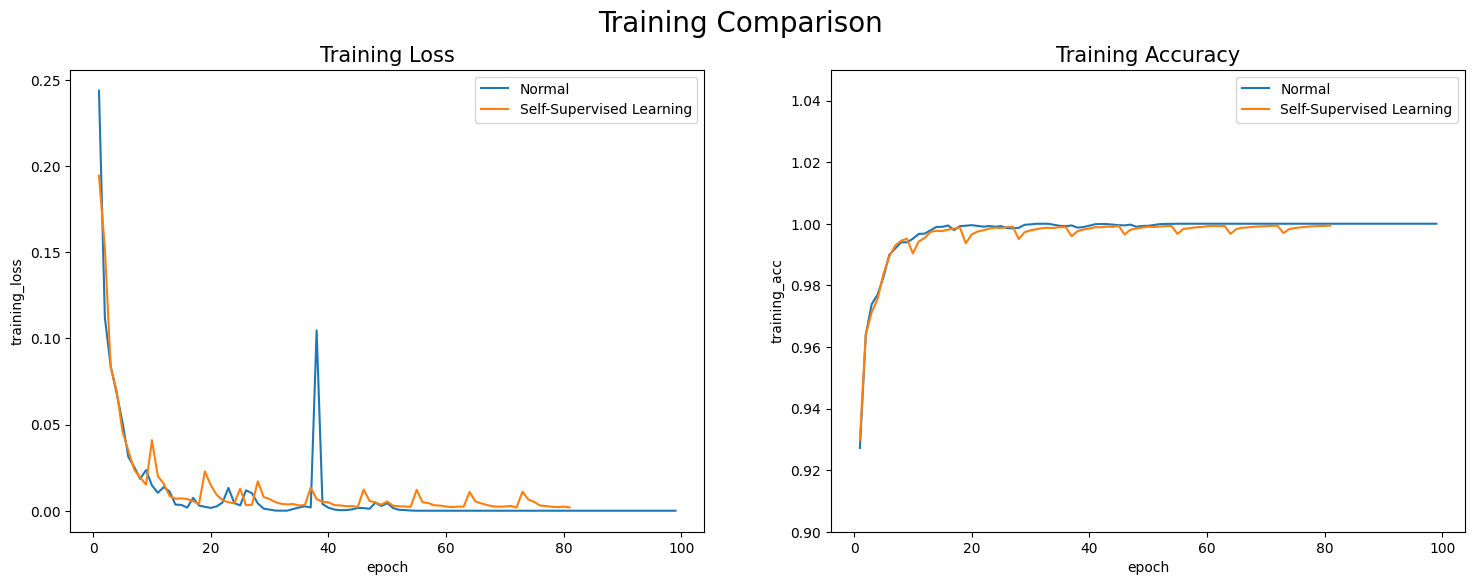

In [34]:
plt.subplots(1,2, figsize=(18,6))
plt.suptitle("Training Comparison ", fontsize=20)
plt.subplot(1,2,1)
sns.lineplot(data=training_logs_df, x="epoch", y="training_loss", label="Normal")
sns.lineplot(data=training_logs_df_ss, x="overall_epoch", y="training_loss", label="Self-Supervised Learning")
plt.title("Training Loss", fontsize=15)
plt.subplot(1,2,2)
sns.lineplot(data=training_logs_df, x="epoch", y="training_acc", label="Normal")
sns.lineplot(data=training_logs_df_ss, x="overall_epoch", y="training_acc", label="Self-Supervised Learning")
plt.ylim(0.9, 1.05)
plt.title("Training Accuracy", fontsize=15)
plt.show()

Below we can observe how the metrics in our validation sets have changed over the training process. We can observe improvements in our metrics after the 100th epoch. Therefore, infer that the self-supervised training routine does make a difference in the quality of model we obtain.

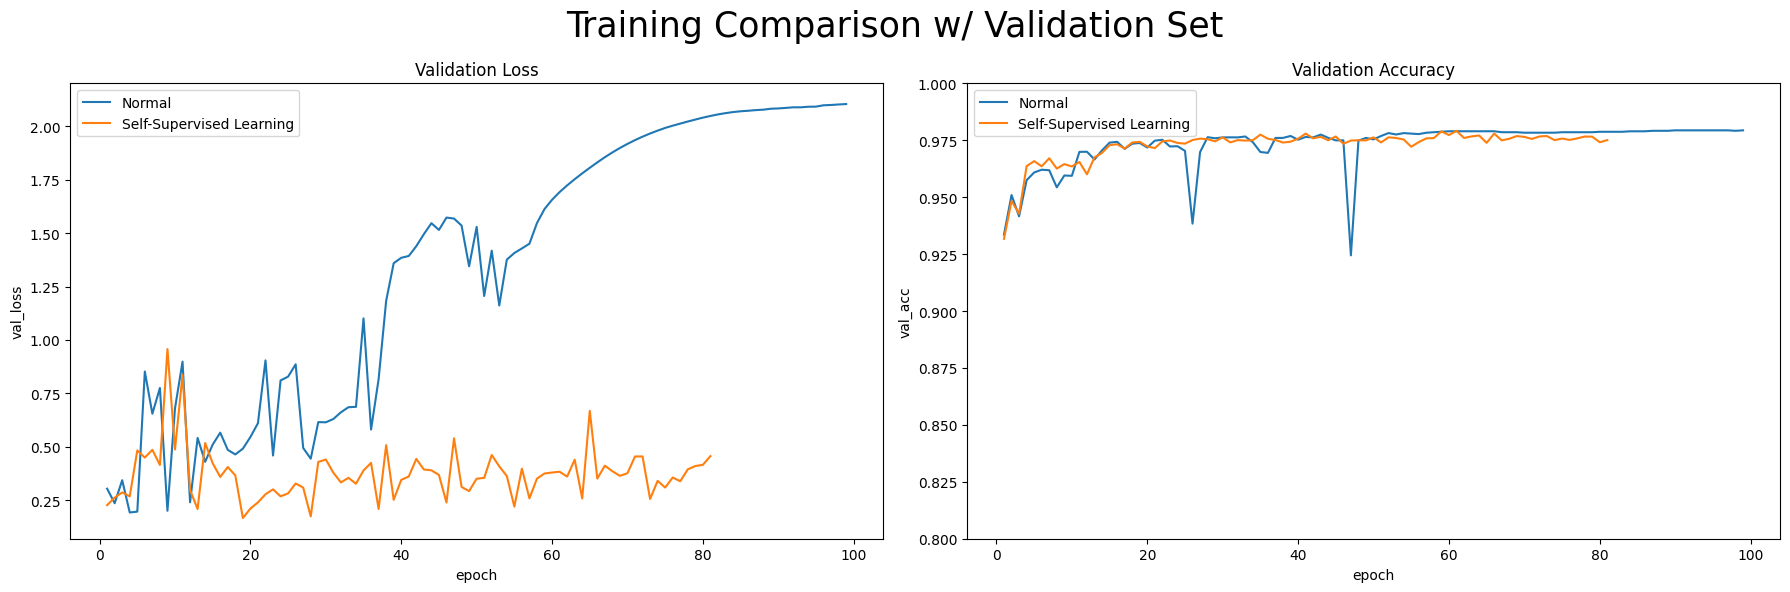

In [29]:
plt.subplots(1,2, figsize=(18,6))
plt.suptitle("Training Comparison w/ Validation Set", fontsize=25)
plt.subplot(1,2,1)
sns.lineplot(data=training_logs_df, x="epoch", y="val_loss", label="Normal")
sns.lineplot(data=training_logs_df_ss, x="overall_epoch", y="val_loss", label="Self-Supervised Learning")
plt.title("Validation Loss")
plt.subplot(1,2,2)
sns.lineplot(data=training_logs_df, x="epoch", y="val_acc", label="Normal")
sns.lineplot(data=training_logs_df_ss, x="overall_epoch", y="val_acc", label="Self-Supervised Learning")
plt.ylim(0.8, 1)
plt.title("Validation Accuracy")
plt.tight_layout()
plt.show()

### Testing of the Model

In [31]:
test_preds_nor, test_ground_truth_nor = t_loop_normal.predictions("test_mask")
test_preds_ss, test_ground_truth_ss = t_loop_self_supervised.predictions("test_mask")

In [32]:
print(classification_report(test_ground_truth_nor, test_preds_nor))

              precision    recall  f1-score   support

         0.0       0.89      0.81      0.85       455
         1.0       0.98      0.99      0.98      4202

    accuracy                           0.97      4657
   macro avg       0.93      0.90      0.91      4657
weighted avg       0.97      0.97      0.97      4657



In [33]:
print(classification_report(test_ground_truth_ss, test_preds_ss))

              precision    recall  f1-score   support

         0.0       0.89      0.81      0.85       455
         1.0       0.98      0.99      0.98      4202

    accuracy                           0.97      4657
   macro avg       0.93      0.90      0.91      4657
weighted avg       0.97      0.97      0.97      4657

